In [14]:
import torch
import numpy as np

class TanhCubed(torch.nn.Module):
    def forward(self, x):
        return torch.tanh(x) ** 3
beta = 10**-3
k = 3
class ExpReLU(torch.nn.Module):
    def forward(self, x):
        return torch.exp(-1 * beta * x**2) * (torch.nn.ReLU()(x) ** k)

class TwoLayerNNTanh(torch.nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(TwoLayerNNTanh, self).__init__()
        self.layer1 = torch.nn.Linear(input_size, hidden_size)  # First layer (trainable)
        self.layer2 = torch.nn.Linear(hidden_size, output_size)  # Second layer (frozen)
        self.activation = TanhCubed()

    def forward(self, x):
        # x = self.activation(self.layer1(x))
        x = torch.tanh(self.layer1(x))
        x = self.layer2(x)  # This layer will not be trained
        return x
    
class TwoLayerNNTanh3(torch.nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(TwoLayerNNTanh3, self).__init__()
        self.layer1 = torch.nn.Linear(input_size, hidden_size)  # First layer (trainable)
        self.layer2 = torch.nn.Linear(hidden_size, output_size)  # Second layer (frozen)
        self.activation = TanhCubed()

    def forward(self, x):
        x = self.activation(self.layer1(x))
        # x = torch.tanh(self.layer1(x))
        x = self.layer2(x)  # This layer will not be trained
        return x

# NNT = TwoLayerNNTanh(3, 30, 3)
# NN3 = TwoLayerNNTanh3(3, 30, 3)


In [15]:
def rad_comp(file_name, size, tflag):
    rad_results = []
    state_dict = torch.load(file_name,weights_only=True,map_location=torch.device('cpu'))
    tflag = True if file_name[2] == "tanh3" else False
    for Nr, state in state_dict.items():
        if tflag:
            NN = TwoLayerNNTanh3(3, size, 3)
        else:
            NN = TwoLayerNNTanh(3, size, 3)
        NN.load_state_dict(state)
        NN.eval()

        a_1 = torch.sum(NN.layer2.weight[:2,:], dim=0)
        a_1m = NN.layer2.weight[:2,:]
        a_2 = NN.layer2.weight[2,:]
        w_x = torch.sum(NN.layer1.weight[:,:-1], dim=-1)
        w_xm = NN.layer1.weight[:,:-1]
        w_t = NN.layer1.weight[:,-1]

        B_f_1 = torch.sum(torch.abs(w_t*a_1))
        B_f_2 = torch.sum(torch.bmm(torch.abs(a_1[:, None] * w_xm).T.unsqueeze(2), torch.abs(a_1m).unsqueeze(1)))
        B_f_3 = torch.sum(torch.abs(w_x*a_2))
        B_f_4 = torch.sum(torch.abs(torch.sum(w_xm * w_xm * a_1[:, None], dim=1)))
        B_f_5 = torch.sum(torch.abs(torch.sum(a_1m.T*w_xm, dim=1)))

        if tflag:
            # tanh^3
            L_s, L_s_p, L_s_pp = 0.75, 1.4, 6
            B_s, B_s_p = 1, 0.75
        else:
            # tanh
            L_s, L_s_p, L_s_pp = 1, 0.8, 2
            B_s, B_s_p = 1, 1

        nu = 0.01
        lambda_0 = 1
        lambda_1 = 0.3
        delta = 1
        N_r = int(Nr[7:])**3
        N_0 = 50**2

        C_z, C_z_0 = 1, 2/3

        B_w = torch.max(torch.norm(NN.layer1.weight, dim=1))
        B_a = torch.sum(torch.abs(a_1))
        # print("B_w =", B_a)

        C = 2*B_f_1*L_s_p + 2*B_f_2*(B_s*L_s_p + B_s_p*L_s) + 2*B_f_3*L_s_p + 4*nu*B_f_4*L_s_pp + 2*lambda_0*B_f_5*L_s_p

        rad_results.append((2*(delta * B_w * ((C_z * C / np.sqrt(N_r)) + (2*lambda_1*C_z_0*B_a / np.sqrt(N_0))))).item())

    return rad_results




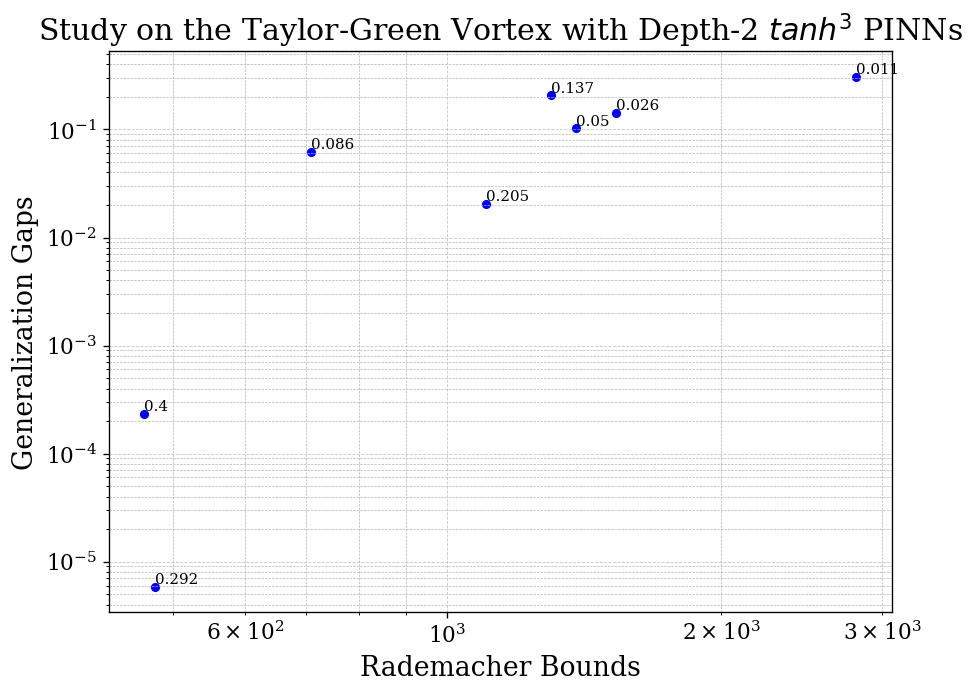

0.9085049531077539


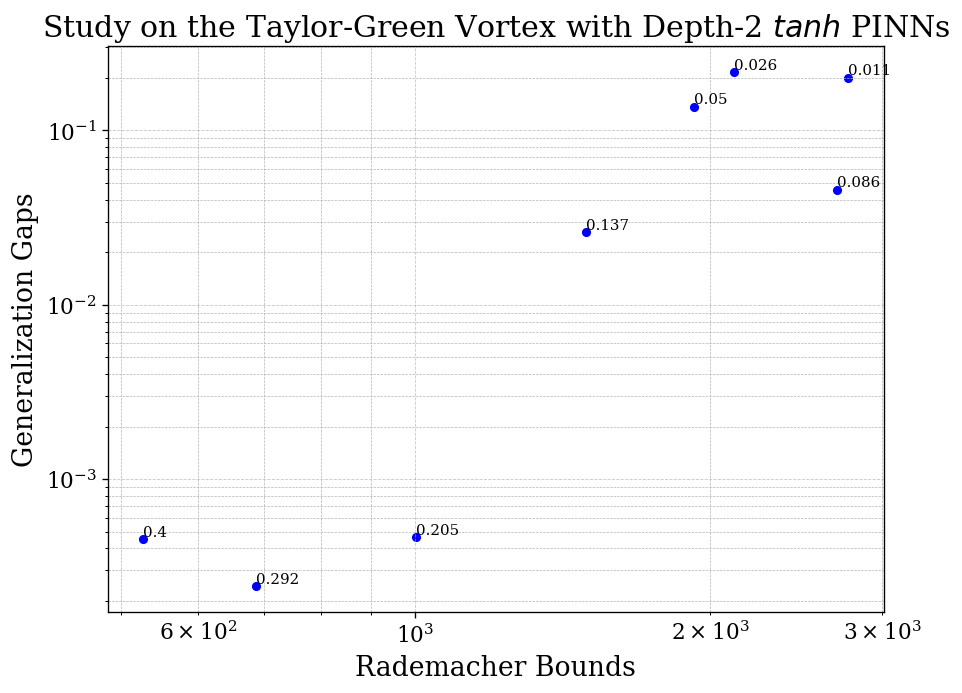

0.722878014178353


In [16]:
import ast
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import os

folder_path = "../old_maybe_useful"
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 14,
    'axes.labelsize': 16,
    'axes.titlesize': 18,
    'legend.fontsize': 14,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'figure.dpi': 120
})

for file_in in os.listdir(folder_path):
    if file_in[0]=='w':
        continue
    file_name = file_in[0:-4]
    weight_name = folder_path + '/weights' + file_name[6:] + '.pt'
    # file_name = f"../result_NS2_tanh_dNs_[30]_Nrs_[3, 4, 5, 6, 7, 8, 9, 10]_i_20000"
    file = file_name.split("_")
    results = np.load(folder_path + "/" + file_name + ".npz")
    train_errors = results['train']
    test_errors = results['test']
    d_Ns = ast.literal_eval(file[4])
    iterations = int(file[8])
    Nrs = np.array(ast.literal_eval(file[6]))
    tf = file[2] == "tanh3"
    tflag = "tanh^3" if tf else file[2]
    ratios = np.round((Nrs ** 3) / (2500), 3)

    rad_results = rad_comp(weight_name, d_Ns[0], tf)
    gap = np.abs(train_errors[:,:,iterations-1] - test_errors[:,:,iterations // 100 - 1])
    plt.figure(figsize=(8,6))
    plt.scatter(rad_results,gap,color="blue", s=20, label='absolute gap')
    # best_fit_line, c = np.polyfit(rad_results, gap, 1)
    # x = np.arange(100, 701)
    # y = best_fit_line * x + c
    # plt.plot(x, y, c='red')
    for i, ratio in enumerate(ratios):
        plt.text(rad_results[i], gap[i], str(ratio), fontsize=9, ha='left', va='bottom')
    plt.yscale('log')
    plt.xscale('log')

    #plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:g}'))

    plt.xlabel("Rademacher Bounds")
    plt.ylabel("Generalization Gaps")
    plt.title(f"Study on the Taylor-Green Vortex with Depth-2 ${tflag}$ PINNs")

    plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
    plt.grid(True, which='minor', linewidth=0.4, linestyle='--')
    plt.tight_layout()
    plt.show()
    print(np.corrcoef(rad_results, gap.squeeze())[0,1])